# Content Challenge: Word Embeddings

Today, we'll learn about word embeddings, visualize them, train a simple embedding model, and see how embeddings help with language tasks. Let's start!


In [1]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 50.8 MB/s eta 0:00:00


In [2]:
# Import Packages

# Pre-trained Word Embedding Models
import gensim.downloader as api

# Word Embedding Functions
from gensim.models import Word2Vec

# Dimensionality Reduction Methods
from sklearn.decomposition import PCA

# General Packages
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## EXERCISE: Visualizing Pre-trained Word Embeddings

Here, we’ll use the `gensim` library to load a small set of pre-trained embeddings (e.g., Word2Vec).

Tasks:
1. Review the available pre-trained models from gensim using `print(api.info()['models'].keys())`, and select one of the models (e.g., 'fasttext-wiki-news-subwords-300'). You can look into the differences of each model. *Each model will have a different vocabulary, so keep that in mind.*
2. Load the selected pre-trained model.
3. Select a few words from the vocabulary of the pre-trained model (e.g. `["king", "queen", "man", "woman", "apple", "fruit"]`), extract their vectorized representation and then print them.
4. Using the dimensionality reduction technique **principle component analysis**, reduce the number of dimensions of the vectorized representations so the information is amenable to plotting (i.e., reduce the dimensions to 2 or 3).
5. Plot the dimensionality reduced vector representations.


### TASK 1: Select a pre-trained model

In [3]:
# TASK 1 EXERCISE

# List all pre-trained models available
print(api.info()['models'].keys())

dict_keys(['fasttext-wiki-news-subwords-300', 'conceptnet-numberbatch-17-06-300', 'word2vec-ruscorpora-300', 'word2vec-google-news-300', 'glove-wiki-gigaword-50', 'glove-wiki-gigaword-100', 'glove-wiki-gigaword-200', 'glove-wiki-gigaword-300', 'glove-twitter-25', 'glove-twitter-50', 'glove-twitter-100', 'glove-twitter-200', '__testing_word2vec-matrix-synopsis'])


### TASK 2: Load the pre-trained model

In [4]:
# TASK 2 EXERCISE

# Load your selected pre-trained embeddings
w2v_model = api.load("word2vec-google-news-300")  # This loads the selected model

[==================================================] 100.0% 1662.8/1662.8MB downloaded


### TASK 3: Extract the vectorized representations of sample words

In [15]:
words_to_extract = ["king", "queen", "man", "woman", "apple", "fruit", "car", "driver", "tree", "flower", "happy", "sad"]

# Filter out words not in the model's vocabulary
words_to_extract = [word for word in words_to_extract if word in w2v_model.key_to_index]
print("Palabras seleccionadas:", words_to_extract)

vectors_list = []
for word in words_to_extract:
  vectors_list.append(w2v_model[word])
#print(vectors_list)
word_vectors = np.array(vectors_list)
print(word_vectors.shape)




Palabras seleccionadas: ['king', 'queen', 'man', 'woman', 'apple', 'fruit', 'car', 'driver', 'tree', 'flower', 'happy', 'sad']
(12, 300)


### TASK 4: Dimensionality Reduction

In [16]:
# TASK 4 EXERCISE

# Reduce dimensions to 2D for visualization

pca = PCA(n_components=2)
word_vectors_2d = pca.fit_transform(word_vectors)

### TASK 5: Visualize the Vector Representations

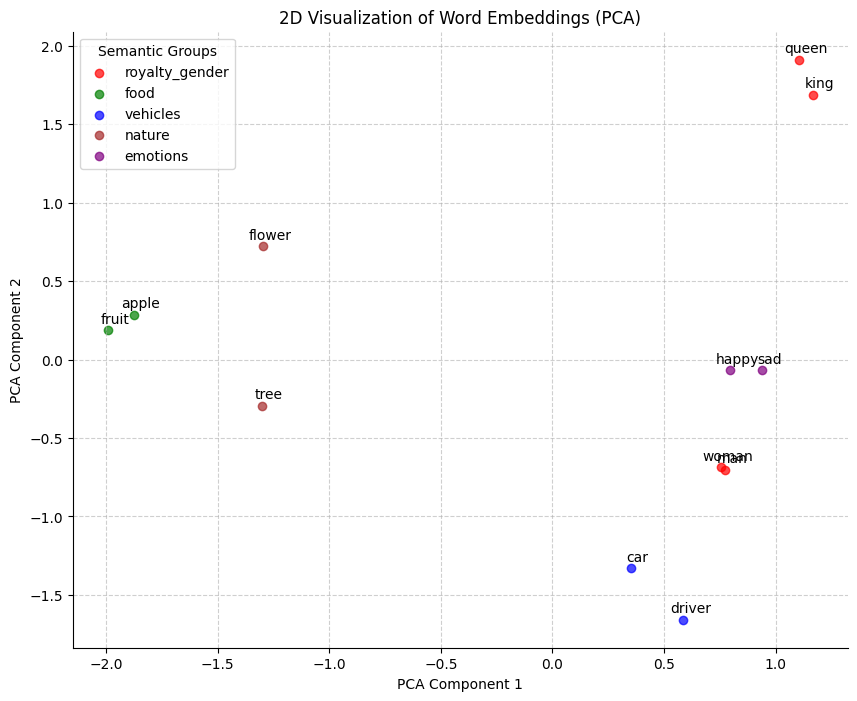

In [22]:
semantic_groups = {
    'royalty_gender': ['king', 'queen', 'man', 'woman'],
    'food': ['apple', 'fruit'],
    'vehicles': ['car', 'driver'],
    'nature': ['tree', 'flower'],
    'emotions': ['happy', 'sad']
}

colors = {
    'royalty_gender': 'red',
    'food': 'green',
    'vehicles': 'blue',
    'nature': 'brown',
    'emotions': 'purple'
}

plt.figure(figsize=(10, 8))

for group, words in semantic_groups.items():
    # Filter words that are actually in our extracted list
    current_group_words = [word for word in words if word in words_to_extract]

    if current_group_words:
        # Get the indices of these words in the words_to_extract list
        indices = [words_to_extract.index(word) for word in current_group_words]

        # Extract the 2D vectors for the current group
        group_vectors_2d = word_vectors_2d[indices]

        # Plot the points for the current group
        plt.scatter(group_vectors_2d[:, 0], group_vectors_2d[:, 1], color=colors[group], label=group, alpha=0.7)

        # Annotate each point with the word label
        for i, word in enumerate(current_group_words):
            plt.annotate(word, (group_vectors_2d[i, 0], group_vectors_2d[i, 1]), textcoords="offset points", xytext=(5,5), ha='center')

plt.title("2D Visualization of Word Embeddings (PCA)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(title="Semantic Groups") # Add a legend to differentiate groups
plt.grid(True, linestyle='--', alpha=0.6)
sns.despine()
plt.show()


## EXERCISE: Train a Simple Word2Vec Model


Tasks:
1. Design your own small text corpus either on your own, from an online source, or using some generative AI tool. This text corpus will be a `list` of sentence `strings`.
2. Tokenize the sentence into individual words.
3. Train a word embedding using `Word2Vec` from `gensim`, or another similar package.
4. Extract the word embeddings for a few example words from your trained model.
5. Visualize the embeddings from your newly trained model.
6. Repeat tasks 1-5 adjusting different parameters to see how it affects the embedding model that is trained. Example parameters or hyperparameters (if you are using the gensim package) that you can adjust include the following: `corpus`, `vector_size`, `window`, `min_count`, etc. Remember, if you increase the vector_size, you will need to do dimensionality reduction to visualize the embedded words.


### TASK 1: Define your corpus

In [28]:
# TASK 1 EXERCISE

corpus = [
    "king is a strong man",
    "queen is a wise woman",
    "man and woman are humans",
    "king and queen rule the kingdom",
    "apple is a fruit",
    "fruit is healthy food",
    "car is a vehicle",
    "driver drives a car",
    "tree and flower are plants",
    "happy people smile",
    "sad people cry",
    "happy and joyful emotions",
    "sad and unhappy emotions"
]

### TASK 2: Tokenize the Corpus

In [29]:
# TASK 2 EXERCISE

# Tokenize the corpus
tokenized_corpus = [sentence.lower().split() for sentence in corpus]
print(tokenized_corpus)

[['king', 'is', 'a', 'strong', 'man'], ['queen', 'is', 'a', 'wise', 'woman'], ['man', 'and', 'woman', 'are', 'humans'], ['king', 'and', 'queen', 'rule', 'the', 'kingdom'], ['apple', 'is', 'a', 'fruit'], ['fruit', 'is', 'healthy', 'food'], ['car', 'is', 'a', 'vehicle'], ['driver', 'drives', 'a', 'car'], ['tree', 'and', 'flower', 'are', 'plants'], ['happy', 'people', 'smile'], ['sad', 'people', 'cry'], ['happy', 'and', 'joyful', 'emotions'], ['sad', 'and', 'unhappy', 'emotions']]


### TASK 3: Train your own Word Embedding Model

In [30]:
# TASK 3 EXERCISE

# Initialize and train the Word2Vec model
my_w2v_model = Word2Vec(
    sentences = tokenized_corpus,   # Input corpus
    vector_size = 50, # Dimensionality of word embeddings
    window = 3,      # Context window size
    min_count = 1,   # Ignore words with frequency lower than this
    workers = 4,                              # Use 4 CPU threads
    sg = 1           # Skip-gram (1) or CBOW (0)
)

### TASK 4: Extract example word embeddings

In [38]:
# TASK 4 EXERCISE
words = ["king", "queen", "man", "woman", "apple", "fruit", "happy", "sad"]
word_embeddings = np.array(
    [my_w2v_model.wv[word] for word in words]
)
print(word_embeddings.shape)

(8, 50)


### TASK 5: Visualize your Embeddings

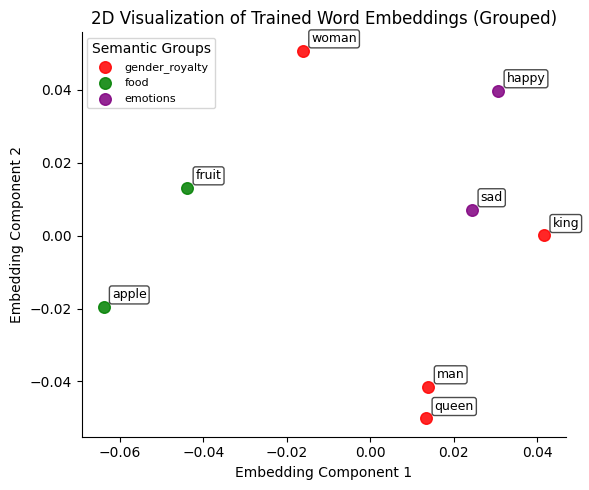

In [40]:
# TASK 5 EXERCISE
# Reduce dimensions to 2D
pca = PCA(n_components=2)
word_embeddings_2d = pca.fit_transform(word_embeddings)

semantic_groups = {
    "gender_royalty": ["king", "queen", "man", "woman"],
    "food": ["apple", "fruit"],
    "emotions": ["happy", "sad"]
}

colors = {
    "gender_royalty": "red",
    "food": "green",
    "emotions": "purple"
}

plt.figure(figsize=(6, 5))

for group, group_words in semantic_groups.items():
    indices = [i for i, w in enumerate(words) if w in group_words]

    plt.scatter(
        word_embeddings_2d[indices, 0],
        word_embeddings_2d[indices, 1],
        color=colors[group],
        label=group,
        s=70,
        alpha=0.85
    )

    for i in indices:
        plt.annotate(
            words[i],
            xy=(word_embeddings_2d[i, 0], word_embeddings_2d[i, 1]),
            xytext=(6, 6),
            textcoords="offset points",
            fontsize=9,
            bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7)
        )

plt.title("2D Visualization of Trained Word Embeddings (Grouped)")
plt.xlabel("Embedding Component 1")
plt.ylabel("Embedding Component 2")
plt.legend(title="Semantic Groups", fontsize=8)
sns.despine()
plt.tight_layout()
plt.show()


## EXERCISE: Determine the Similarity of Sentences

Here, you will explore the concept of capturing the similarity of words and groups of words in vector space.

Tasks:
1. Calculate the most similar words of your pre-trained model `w2v_model` to an example word (e.g., king) from the model's vocabulary using pre-built functions from `gensim` or a package of your choice.
2. Calculate the similarity between two words in the vocabulary of your pre-trained model `w2v_model` (e.g., "king" and "queen" or "apple" and "fruit") using pre-built functions from `gensim` or a package of your choice.
3. Develop a method to calculate the similarity between two sentences (e.g., "king and queen" with "man and woman"). Consider how you can create a summary vector of a sentence. Here you can use the imported function `cosine` from `scipy.spatial.distance` once you have created a summary vector of each sentence.


### TASK 1: Find similar words to a given word

In [42]:
# TASK 1 EXERCISE
word_1 = "king"
word_2 = "apple"

similar_words_1 = w2v_model.wv.most_similar(word_1, topn=5)
similar_words_2 = w2v_model.wv.most_similar(word_2, topn=5)

print("Words similar to " + word_1 + ":", similar_words_1)
print("Words similar to " + word_2 + ":", similar_words_2)

Words similar to king: [('people', 0.3066342771053314), ('plants', 0.26736629009246826), ('queen', 0.19099856913089752), ('sad', 0.15392154455184937), ('and', 0.15056748688220978)]
Words similar to apple: [('fruit', 0.31560027599334717), ('drives', 0.15493643283843994), ('queen', 0.1525689661502838), ('is', 0.14328601956367493), ('cry', 0.11321883648633957)]


### TASK 2: Find the similarity between two words

In [44]:
# TASK 2 EXERCISE
# TASK 2 EXERCISE
word_to_compare_1 = "king"
word_to_compare_2 = "queen"

word_pair_similarity = w2v_model.wv.similarity(word_to_compare_1, word_to_compare_2)

print("Similarity between " + word_to_compare_1 + " and " + word_to_compare_2 + ":", word_pair_similarity)


Similarity between king and queen: 0.19099857


### TASK 3: Find the similarity between two sentences

In [45]:
# TASK 3 EXERCISE

def sentence_vector(sentence, model):
    '''Create a function which, given a word embedding model, and a sentence,
       produces a vector representation of the sentence.
    '''

    ords = sentence.lower().split()

    valid_vectors = [
        model.wv[word] for word in words if word in model.wv
    ]

    if len(valid_vectors) == 0:
        return np.zeros(model.vector_size)

    return np.mean(valid_vectors, axis=0)

# Define two example sentences
sentence_1 = "king and queen"
sentence_2 = "man and woman"

# Calculate cosine similarity between the sentence embeddings
from scipy.spatial.distance import cosine

vector1 = sentence_vector(sentence_1, w2v_model)
vector2 = sentence_vector(sentence_2, w2v_model)
similarity = 1 - cosine(vector1, vector2)

print(f"Similarity between '{sentence_1}' and '{sentence_2}':", similarity)

Similarity between 'king and queen' and 'man and woman': 1.0
